# Fine-Tuning BERT for SMS Spam Detection

**Assignment:** Transformers, Attention, and Modern NLP  
**Task:** Binary text classification — SMS spam vs ham  
**Model:** `google-bert/bert-base-uncased`  
**Dataset:** `ucirvine/sms_spam`

This notebook fine-tunes a pretrained BERT model using the Hugging Face `Trainer` API.  
It includes preprocessing, tokenization with attention masks, class imbalance handling, training, evaluation, visualizations, and business-impact-ready results.

> Recommended Colab setting: **Runtime → Change runtime type → GPU**.


In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


## 2. Import libraries

In [ ]:
import os
import inspect
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset, DatasetDict, ClassLabel, Features, Value
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
def load_sms_spam_dataset():
    try:
        raw_dataset = load_dataset("ucirvine/sms_spam")
        dataset = raw_dataset["train"]
        print("Loaded dataset from Hugging Face: ucirvine/sms_spam")
        return dataset
    except Exception as e:
        print("Hugging Face load failed. Trying UCI fallback...")
        print("Original error:", repr(e))

        import io
        import zipfile
        import requests

        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
        response = requests.get(url)
        response.raise_for_status()

        z = zipfile.ZipFile(io.BytesIO(response.content))
        with z.open("SMSSpamCollection") as f:
            df = pd.read_csv(f, sep="\t", names=["label_text", "sms"], header=None)

        df["label"] = df["label_text"].map({"ham": 0, "spam": 1})
        df = df[["sms", "label"]].dropna()

        features = Features({
            "sms": Value("string"),
            "label": ClassLabel(names=["ham", "spam"])
        })

        dataset = Dataset.from_pandas(df, features=features, preserve_index=False)
        print("Loaded dataset from UCI fallback.")
        return dataset

dataset = load_sms_spam_dataset()

print(dataset)
print(dataset.column_names)
print(dataset.features)
print(dataset[0])


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

Loaded dataset from Hugging Face: ucirvine/sms_spam
Dataset({
    features: ['sms', 'label'],
    num_rows: 5574
})
['sms', 'label']
{'sms': Value('string'), 'label': ClassLabel(names=['ham', 'spam'])}
{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}


In [ ]:
# Identify the text column automatically.
text_col = None

for col in dataset.column_names:
    try:
        if dataset.features[col].dtype == "string":
            text_col = col
            break
    except Exception:
        pass

label_col = "label"

print("Text column:", text_col)
print("Label column:", label_col)

if text_col is None:
    raise ValueError("No text column was found. Please inspect dataset.column_names.")


Text column: sms
Label column: label


In [ ]:
# Make sure labels are a ClassLabel type.
if not isinstance(dataset.features[label_col], ClassLabel):
    dataset = dataset.class_encode_column(label_col)

label_names = dataset.features[label_col].names
num_labels = len(label_names)

print("Label names:", label_names)
print("Number of labels:", num_labels)


Label names: ['ham', 'spam']
Number of labels: 2


In [ ]:
train_test = dataset.train_test_split(
    test_size=0.20,
    seed=42,
    stratify_by_column=label_col
)

valid_test = train_test["test"].train_test_split(
    test_size=0.50,
    seed=42,
    stratify_by_column=label_col
)

dataset_split = DatasetDict({
    "train": train_test["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"]
})

dataset_split


DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 4459
    })
    validation: Dataset({
        features: ['sms', 'label'],
        num_rows: 557
    })
    test: Dataset({
        features: ['sms', 'label'],
        num_rows: 558
    })
})

In [ ]:
train_df = dataset_split["train"].to_pandas()
val_df = dataset_split["validation"].to_pandas()
test_df = dataset_split["test"].to_pandas()

print("Training class counts:")
print(train_df[label_col].value_counts().sort_index())

print("\nValidation class counts:")
print(val_df[label_col].value_counts().sort_index())

print("\nTest class counts:")
print(test_df[label_col].value_counts().sort_index())

class_count_table = pd.DataFrame({
    "class_id": range(num_labels),
    "class_name": label_names,
    "train_count": [int((train_df[label_col] == i).sum()) for i in range(num_labels)],
    "validation_count": [int((val_df[label_col] == i).sum()) for i in range(num_labels)],
    "test_count": [int((test_df[label_col] == i).sum()) for i in range(num_labels)]
})

class_count_table


Training class counts:
label
0    3861
1     598
Name: count, dtype: int64

Validation class counts:
label
0    483
1     74
Name: count, dtype: int64

Test class counts:
label
0    483
1     75
Name: count, dtype: int64


,class_id,class_name,train_count,validation_count,test_count
0,0,ham,3861,483,483
1,1,spam,598,74,75


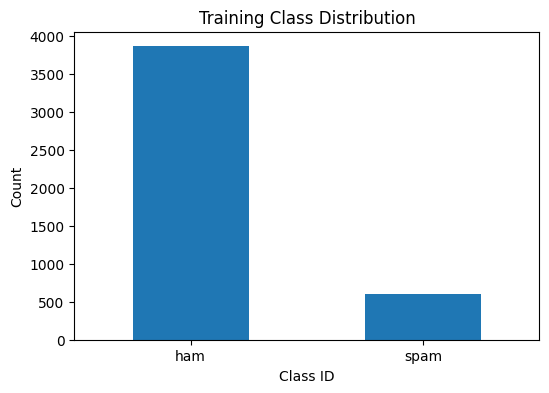

In [ ]:
plt.figure(figsize=(6, 4))
train_df[label_col].value_counts().sort_index().plot(kind="bar")
plt.title("Training Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.xticks(ticks=range(num_labels), labels=label_names, rotation=0)
plt.show()


In [ ]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

baseline.fit(train_df[text_col], train_df[label_col])

baseline_preds = baseline.predict(test_df[text_col])

if hasattr(baseline.named_steps["clf"], "predict_proba"):
    baseline_probs = baseline.predict_proba(test_df[text_col])[:, 1]
else:
    baseline_probs = None

print("Baseline Classification Report")
print(classification_report(
    test_df[label_col],
    baseline_preds,
    target_names=label_names,
    zero_division=0
))

baseline_acc = accuracy_score(test_df[label_col], baseline_preds)
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    test_df[label_col],
    baseline_preds,
    average="binary",
    zero_division=0
)

try:
    baseline_auc = roc_auc_score(test_df[label_col], baseline_probs) if baseline_probs is not None else np.nan
except Exception:
    baseline_auc = np.nan

baseline_metrics = {
    "model": "TF-IDF + Logistic Regression",
    "accuracy": baseline_acc,
    "precision": baseline_precision,
    "recall": baseline_recall,
    "f1": baseline_f1,
    "auc": baseline_auc
}

baseline_metrics


Baseline Classification Report
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       483
        spam       0.96      0.92      0.94        75

    accuracy                           0.98       558
   macro avg       0.97      0.96      0.96       558
weighted avg       0.98      0.98      0.98       558



{'model': 'TF-IDF + Logistic Regression',
 'accuracy': 0.9838709677419355,
 'precision': 0.9583333333333334,
 'recall': 0.92,
 'f1': 0.9387755102040817,
 'auc': np.float64(0.9758730158730159)}

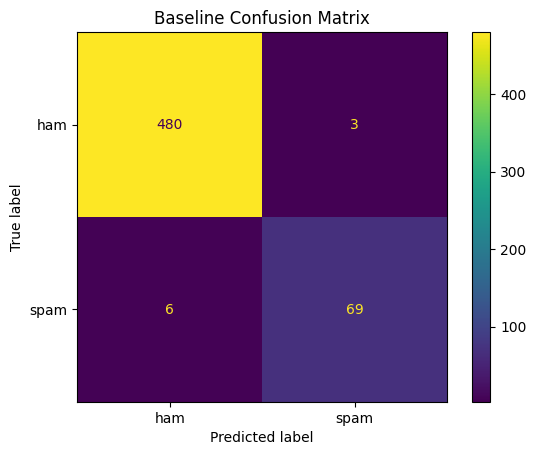

In [ ]:
baseline_cm = confusion_matrix(test_df[label_col], baseline_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=label_names
)

disp.plot(values_format="d")
plt.title("Baseline Confusion Matrix")
plt.show()


In [ ]:
model_name = "google-bert/bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

print("Loaded:", model_name)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: google-bert/bert-base-uncased


In [ ]:
max_length = 128

def tokenize_function(batch):
    return tokenizer(
        batch[text_col],
        truncation=True,
        padding=False,
        max_length=max_length
    )

tokenized_dataset = dataset_split.map(tokenize_function, batched=True)

# Rename label column to labels because Trainer expects the label column to be named labels.
tokenized_dataset = tokenized_dataset.rename_column(label_col, "labels")

# Keep only the columns needed by BERT.
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_dataset


Map:   0%|          | 0/4459 [00:00<?, ? examples/s]

Map:   0%|          | 0/557 [00:00<?, ? examples/s]

Map:   0%|          | 0/558 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sms', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4459
    })
    validation: Dataset({
        features: ['sms', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 557
    })
    test: Dataset({
        features: ['sms', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 558
    })
})

In [ ]:
def stable_softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    preds = np.argmax(logits, axis=-1)
    probs = stable_softmax(logits)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except Exception:
        auc = np.nan

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }


In [ ]:
train_labels = np.array(dataset_split["train"][label_col])

class_counts = np.bincount(train_labels, minlength=num_labels)
class_weights = len(train_labels) / (num_labels * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class counts:", class_counts)
print("Class weights:", class_weights)


Class counts: [3861  598]
Class weights: tensor([0.5774, 3.7283])


In [ ]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        model_inputs = {k: v for k, v in inputs.items() if k != "labels"}

        outputs = model(**model_inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss


In [ ]:
training_args_signature = inspect.signature(TrainingArguments.__init__).parameters

training_args_dict = {
    "output_dir": "./bert_sms_spam_results",
    "save_strategy": "epoch",
    "logging_strategy": "steps",
    "logging_steps": 25,
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "num_train_epochs": 3,
    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "lr_scheduler_type": "linear",
    "max_grad_norm": 1.0,
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "greater_is_better": True,
    "report_to": []
}

if "eval_strategy" in training_args_signature:
    training_args_dict["eval_strategy"] = "epoch"
else:
    training_args_dict["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_args_dict)

print(training_args)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [ ]:
trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": tokenized_dataset["train"],
    "eval_dataset": tokenized_dataset["validation"],
    "data_collator": data_collator,
    "compute_metrics": compute_metrics
}

# Some Transformers versions accept processing_class; some do not.
# This is optional, but useful when supported.
trainer_signature = inspect.signature(Trainer.__init__).parameters

if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

train_result = trainer.train()

print("Training complete.")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.039465,0.115741,0.989228,0.972222,0.945946,0.958904,0.999608
2,0.046114,0.009828,0.998205,1.000000,0.986486,0.993197,1.000000
3,0.000510,0.015359,0.996409,0.986486,0.986486,0.986486,0.999972


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete.


In [ ]:
val_results = trainer.evaluate(eval_dataset=tokenized_dataset["validation"])
val_results


{'eval_loss': 0.009768206626176834,
 'eval_accuracy': 0.9982046678635548,
 'eval_precision': 1.0,
 'eval_recall': 0.9864864864864865,
 'eval_f1': 0.9931972789115646,
 'eval_auc': 1.0,
 'eval_runtime': 2.5335,
 'eval_samples_per_second': 219.853,
 'eval_steps_per_second': 13.815,
 'epoch': 3.0}

In [ ]:
test_output = trainer.predict(tokenized_dataset["test"])

test_logits = test_output.predictions
test_labels = test_output.label_ids
test_preds = np.argmax(test_logits, axis=-1)

test_probs = stable_softmax(test_logits)

print("BERT Test Classification Report")
print(classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    zero_division=0
))

bert_acc = accuracy_score(test_labels, test_preds)
bert_precision, bert_recall, bert_f1, _ = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average="binary",
    zero_division=0
)

try:
    bert_auc = roc_auc_score(test_labels, test_probs[:, 1])
except Exception:
    bert_auc = np.nan

bert_metrics = {
    "model": "Fine-tuned BERT",
    "accuracy": bert_acc,
    "precision": bert_precision,
    "recall": bert_recall,
    "f1": bert_f1,
    "auc": bert_auc
}

bert_metrics


BERT Test Classification Report
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       483
        spam       0.95      0.93      0.94        75

    accuracy                           0.98       558
   macro avg       0.97      0.96      0.97       558
weighted avg       0.98      0.98      0.98       558



{'model': 'Fine-tuned BERT',
 'accuracy': 0.9838709677419355,
 'precision': 0.9459459459459459,
 'recall': 0.9333333333333333,
 'f1': 0.9395973154362416,
 'auc': np.float64(0.9977087646652865)}

## 18. BERT confusion matrix

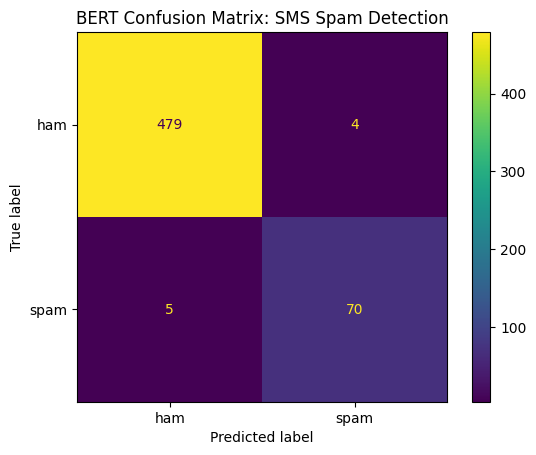

In [ ]:
bert_cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=bert_cm,
    display_labels=label_names
)

disp.plot(values_format="d")
plt.title("BERT Confusion Matrix: SMS Spam Detection")
plt.show()


## 19. Training loss, validation loss, and learning rate schedule

In [ ]:
logs = pd.DataFrame(trainer.state.log_history)
logs.head()


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.741221,6.987665,0.000006,0.089606,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.486282,8.601814,0.000012,0.179211,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.180434,1.024654,0.000018,0.268817,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.125441,4.039401,0.000020,0.358423,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.091849,1.511603,0.000019,0.448029,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


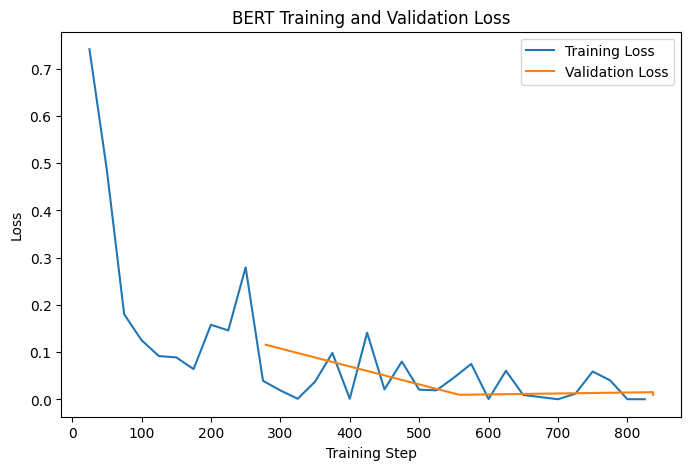

In [ ]:
train_logs = logs[logs["loss"].notna()] if "loss" in logs.columns else pd.DataFrame()
eval_logs = logs[logs["eval_loss"].notna()] if "eval_loss" in logs.columns else pd.DataFrame()

plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")

if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss")

plt.title("BERT Training and Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.show()


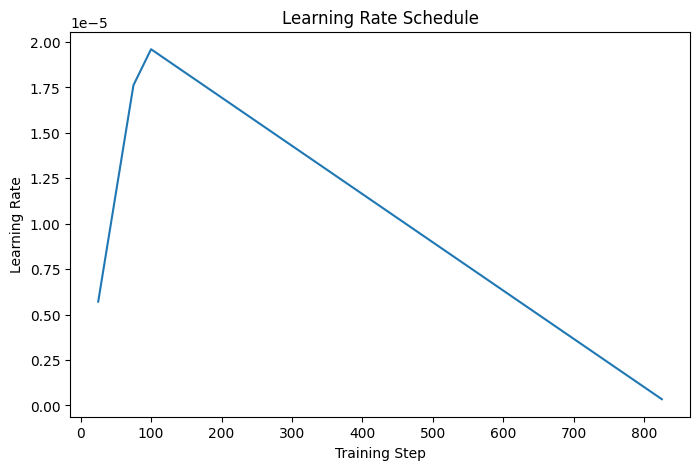

In [ ]:
if "learning_rate" in train_logs.columns and len(train_logs) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(train_logs["step"], train_logs["learning_rate"])
    plt.title("Learning Rate Schedule")
    plt.xlabel("Training Step")
    plt.ylabel("Learning Rate")
    plt.show()
else:
    print("Learning rate values were not found in the logs.")


## 20. Compare baseline vs BERT

In [ ]:
results_df = pd.DataFrame([baseline_metrics, bert_metrics])

# Round values for clearer reporting.
display_results = results_df.copy()
for col in ["accuracy", "precision", "recall", "f1", "auc"]:
    display_results[col] = display_results[col].astype(float).round(4)

display_results


,model,accuracy,precision,recall,f1,auc
0,TF-IDF + Logistic Regression,0.9839,0.9583,0.9200,0.9388,0.9759
1,Fine-tuned BERT,0.9839,0.9459,0.9333,0.9396,0.9977


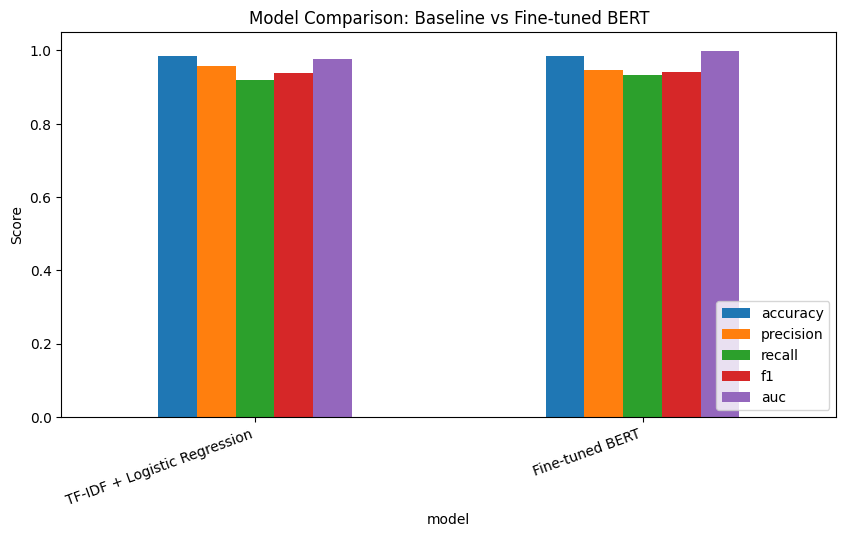

In [ ]:
results_df.set_index("model")[["accuracy", "precision", "recall", "f1", "auc"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Comparison: Baseline vs Fine-tuned BERT")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.show()


In [ ]:
def predict_sms(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    # Move inputs to the same device as the model.
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    pred_id = int(np.argmax(probs))

    return {
        "text": text,
        "prediction": label_names[pred_id],
        "confidence": round(float(probs[pred_id]), 4),
        "ham_probability": round(float(probs[0]), 4),
        "spam_probability": round(float(probs[1]), 4)
    }


In [ ]:
example_messages = [
    "Congratulations! You have won a free prize. Click here to claim now.",
    "Hey, are we still meeting for class tomorrow?",
    "Urgent! Your account has been locked. Verify your details immediately.",
    "Can you call me when you get home?"
]

for msg in example_messages:
    print(predict_sms(msg))


{'text': 'Congratulations! You have won a free prize. Click here to claim now.', 'prediction': 'spam', 'confidence': 0.9995, 'ham_probability': 0.0005, 'spam_probability': 0.9995}
{'text': 'Hey, are we still meeting for class tomorrow?', 'prediction': 'ham', 'confidence': 0.9979, 'ham_probability': 0.9979, 'spam_probability': 0.0021}
{'text': 'Urgent! Your account has been locked. Verify your details immediately.', 'prediction': 'spam', 'confidence': 0.6152, 'ham_probability': 0.3848, 'spam_probability': 0.6152}
{'text': 'Can you call me when you get home?', 'prediction': 'ham', 'confidence': 0.9984, 'ham_probability': 0.9984, 'spam_probability': 0.0016}


In [ ]:
os.makedirs("outputs", exist_ok=True)

results_df.to_csv("outputs/model_comparison_results.csv", index=False)
logs.to_csv("outputs/training_logs.csv", index=False)

trainer.save_model("outputs/fine_tuned_bert_sms_spam")
tokenizer.save_pretrained("outputs/fine_tuned_bert_sms_spam")

print("Saved model, tokenizer, training logs, and model comparison results in the outputs folder.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model, tokenizer, training logs, and model comparison results in the outputs folder.
